# Import libraries

In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import argparse

import sys
sys.path.append("..")
from ml_solver import MLSolver, DeepONet, FNOforPDE, DeepONetCNN
from data_generation import GaussianRandomField, PDEDataset2, GaussianRandomFieldHierarchical
from pde import PoissonEquation1D, PoissonEquation2D, HelmholtzEquation1D, HelmholtzEquation2D, ConvectionDiffusion2D
from numerical_solver import WeightedJacobiSolver, MultigridSolver, GaussSeidelSolver
from hybrid_solver import Router, ConstantRouter, HINTSRouter, LSTMGreedyRouter, HybridSolver, LSTMGreedyRouter_SideInfo


from trainer import Trainer, EarlyStopping, ApproxGreedyRouterLoss, ScheduledSampler
import json
import latextable
import pickle
import pandas as pd
from texttable import Texttable

In [2]:
max_iters = 100

# Function to test any given hybrid solver

In [3]:
def test_model(model, dataloader, in_channels, dim, loss = ApproxGreedyRouterLoss(), centered = True, loss_t = False):
    model.eval()
    errors_greedy = ()
    loss_greedy = () if loss_t else None
    residuals = ()
    solver_decisions = ()
    mode_1_errors = ()
    mode_5_errors = ()
    mode_10_errors = ()
    with torch.no_grad():
        for batch in dataloader:
            model.reset()
            input, output = batch
            bs = input.shape[0]
            # f = input[:, 0, :].reshape(bs, -1)
            # if in_channels > 1:
            #     a = input[:, 1, :].reshape(bs, -1)
            # else:
            #     a = None
            f = input[:, -1, :].reshape(bs, -1)
            if model.equation.equation in ["Poisson", "ConvDiff"]:
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            pred = model(f = f, a = a, k2 = k2, u0=None, return_dict = True, training=loss, ground_truth = output.reshape(bs, -1))
            if centered:
                predictions = pred["predictions"] - torch.mean(pred["predictions"], axis = 2, keepdim = True)
            else:
                predictions =  pred["predictions"] 
            initial_prediction = torch.zeros_like(predictions[0]).unsqueeze(0)
            predictions = torch.cat((initial_prediction, predictions), dim = 0)
            # initial_error = torch.norm()
            error = torch.norm(predictions - output.reshape(bs, -1).unsqueeze(0), dim=2).detach().cpu().numpy()
            scores = pred["routing_scores"]
            decisions = torch.argmax(scores, dim = -1).detach().cpu().numpy()
            solver_decisions += (decisions,)
            residual = torch.norm(pred["residuals"], dim = 2).detach().cpu().numpy()
            residuals += (residual, )
            errors_greedy += (error,)
            if loss_t:
                loss_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            error = (predictions - output.reshape(bs, -1).unsqueeze(0)).detach().cpu().numpy()
                        
            if dim == 1:
                mode_wise_error = np.fft.rfftn(error, axes = [-1])
                mode_1_error = mode_wise_error[:, :, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)

            else:
                N = int(np.sqrt(error.shape[2]))
                error = error.reshape(error.shape[0], error.shape[1], N, N)
                mode_wise_error = np.fft.rfftn(error, axes = [-2,-1])
                mode_1_error = mode_wise_error[:, :, 1, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)
            mode_1_errors += (mode_1_norm,)
            mode_5_errors += (mode_5_norm,)
            mode_10_errors += (mode_10_norm,)

    errors_greedy = np.concatenate(errors_greedy, axis = 1)
    loss_greedy = np.concatenate(loss_greedy) if loss_t else None
    residuals = np.concatenate(residuals, axis = 1)
    mode_1_errors = np.concatenate(mode_1_errors, axis = 1)
    mode_5_errors = np.concatenate(mode_5_errors, axis = 1)
    mode_10_errors = np.concatenate(mode_10_errors, axis = 1)
    solver_decisions = np.concatenate(solver_decisions, axis = 1)
    return errors_greedy, loss_greedy, residuals, mode_1_errors, mode_5_errors, mode_10_errors, solver_decisions


In [4]:
def visualize_predictions_truth(deeponet, dataloader):
    need_mean_zero = (equation == "Poisson") or (equation == "ConvDiff" or reaction_c == 0)
    with torch.no_grad():
        for batch in dataloader:
            input, output = batch
            bs = input.shape[0]
            print(input.shape)
            # if input.shape[1] > 1:
            #     input = input[:, -1, :].reshape(bs, -1)
            pred = deeponet(input)
            print(pred.shape)
            pred = pred - torch.mean(pred, dim = (1, 2), keepdim = True) if need_mean_zero and boundary == "Periodic" and in_channels == 1 else pred
            break
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    print(pred.shape)
    print(output.shape)
    # mse = torch.linalg.norm(pred - output, dim = (1,2))/torch.linalg.norm(output, dim = (1,2))
    # print(mse)
    # make sure all plots in the same column have the same color bar
    # datasets = [[pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)] for i in range(4)]
    # norm = Normalize(vmin = np.min(datasets), vmax = np.max(datasets))
    for i in range(4):
        datasets = [pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)]
        norm = Normalize(vmin = np.min(datasets[1]), vmax = np.max(datasets[1]))
        if i == 2:
            print(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N)[0])
            print(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)[0])
        axs[0][i].imshow(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm)
        axs[0][i].set_title(f"Truth: sample {i}")
        axs[1][i].imshow(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm)
        axs[1][i].set_title(f"Predicted: sample {i}")
        cbar = axs[1][i].figure.colorbar(axs[1][i].imshow(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm), ax = axs[1][i])
        cbar = axs[0][i].figure.colorbar(axs[0][i].imshow(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm), ax = axs[0][i])
    plt.show()

                

# Function to test the true greedy hybrid solver

In [5]:
def true_greedy_model(model_hints, test_loader):
    errors_true_greedy = ()
    loss_true_greedy = ()
    best_solvers = ()
    with torch.no_grad():
        for batch in test_loader:
            model_hints.reset()
            input, output = batch
            bs = input.shape[0]
            f = input[:, -1, :].reshape(bs, -1)
            if model_hints.equation.equation in ["Poisson", "ConvDiff"]:
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            
            pred = model_hints(f = f, a = a, k2=k2, u0=None, return_dict = True, training=True, teacher_forcing = 1.0, ground_truth = output.reshape(bs, -1))
            if model_hints.equation.equation == "Poisson" and model_hints.equation.boundary == "Periodic":
                expert_predictions = pred["complete_expert_predictions"] - torch.mean(pred["complete_expert_predictions"], dim=-1, keepdim=True)
            else:
                expert_predictions = pred["complete_expert_predictions"]
            print(expert_predictions.shape)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_solver = torch.argmin(errors_expert, dim=1)
            scores = torch.zeros(max_iters, input.shape[0], 2, device = device)
            scores = torch.nn.functional.one_hot(best_solver, num_classes=2).to(scores.dtype)
            pred["routing_scores"] = scores 
            
            loss_true_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            initial_prediction = torch.zeros_like(expert_predictions[0]).unsqueeze(0)
            expert_predictions = torch.cat((initial_prediction, expert_predictions), dim = 0)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_error = torch.min(errors_expert, dim=1).values.detach().cpu().numpy()
            errors_true_greedy += (best_error,)
            best_solvers += (best_solver.detach().cpu().numpy(),)
    errors_true_greedy = np.concatenate(errors_true_greedy, axis=1)
    loss_true_greedy = np.concatenate(loss_true_greedy)
    best_solvers = np.concatenate(best_solvers, axis=1)
    return errors_true_greedy, best_solvers

# Set the parameters

In [6]:
ml_model_type = "deeponet"
ml_model_name = "msealphaepsilon_loss_new_data4"
model_type = "lstm_side_info"
model_name = "side_info_deeponet"
equation = "ConvDiff"
boundary = "Periodic"
dim = 2
in_channels = 1
ckp_dir = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints"
solvers = "mg" # "jacobi_0.5,jacobi_0.67,jacobi_0.75,jacobi_0.8,jacobi"#,jacobi,jacobi_0.8"
grf_mode = "hierarchical"
n_samples = 64
n_test = n_samples
b_vel = 20.0
reaction_c = 0.0
data_dir = "/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/data"
data_name = "new_new_new_"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generate = True

# Load the ML solver arguments and Router arguments

In [7]:
ml_ckp_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_best.pth"
ml_args_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_args.json"

args_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}args.json"
print(args_path)
if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
    
if os.path.exists(ml_args_path):
    print('Loadargs')
    with open(ml_args_path, "r") as f:
        ml_arguments = json.load(f)
else:
    raise ValueError("ML Args Path Not found")

/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstm_side_inforouter_side_info_deeponet_ConvDiff_Periodic_2d_1c_mgargs.json
Loadargs


# Generate some test data

In [8]:
if os.path.exists(f"{data_dir}/{data_name}router_test_data_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{n_test}s.pt"):
    print(f"Loading data from {data_dir}...")
    with open(f"{data_dir}/{data_name}router_test_data_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{n_test}s.pt", "rb") as f:
        test_data = torch.load(f)
if generate:
# else:
    if grf_mode == "fixed":
        with open(f"../args/grf_args.json", "r") as f:
            arguments_grf = json.load(f)
        grf = GaussianRandomField(num_samples=ml_arguments["N"],
                                    dim=dim,
                                    alpha=arguments_grf["alpha"],
                                    beta=arguments_grf["beta"],
                                    gamma=arguments_grf["gamma"],
                                    device=device,
                                    seed = 72)
    else:
        with open(f"../args/hierarchical_grf.json", "r") as f:
            arguments_grf = json.load(f)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        grf = GaussianRandomFieldHierarchical(num_samples=ml_arguments["N"],dim=dim,
                                                alpha_min=arguments_grf["alpha_min"],
                                                        alpha_max=arguments_grf["alpha_max"],
                                                        beta_min=arguments_grf["beta_min"],
                                                        beta_max=arguments_grf["beta_max"],
                                                        gamma_list=arguments_grf["gamma_list"],
                                                        device=device, seed=4)

    pushforward = None if boundary == "Dirichlet" else lambda x: x - torch.mean(x)
    if dim == 1:
        pushforward = lambda x: x - torch.mean(x, dim=-1, keepdim=True)
    else:
        pushforward = lambda x: x - torch.mean(x, dim=(-2, -1), keepdim=True)
    needs_mean_zero = (equation == "Poisson") or (equation == "ConvDiff" and reaction_c == 0.0)
    f = grf.generate(n_samples, pushfoward=pushforward) if needs_mean_zero and boundary == "Periodic" and in_channels == 1 else grf.generate(n_samples, pushfoward=None)
    # if equation == "Poisson" or (equation == "Helmholtz" and in_channels > 1):
    #     f = grf.generate(n_samples, pushfoward=pushforward) if equation == "Poisson" and in_channels == 1 else grf.generate(n_samples, pushfoward=None)
    # else:
    #     if dim == 1:
    #         f = lambda x: 0.0
    #     else:
    #         f = lambda x, y: 0.0

    k2 = grf.generate(n_samples)
    if in_channels > 1:
        a = grf.generate(n_samples)
    else:
        if dim == 1:
            a = lambda x: 1.0
        else:
            a = lambda x, y: 1.0
    if boundary == "Dirichlet":
        x = torch.linspace(0, 1, ml_arguments["N"], device=device, dtype=torch.float32)
        y = torch.linspace(0, 1, ml_arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
    else:
        x = torch.linspace(0, 1, ml_arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
        y = torch.linspace(0, 1, ml_arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None

    # Here I want to leverage our new batch friendly pde objects
    pde = None
    u_sol = None
    if dim == 1:
        if equation == "Poisson":
            pde = PoissonEquation1D(a_func=a, 
                                    f_func=f, 
                                    boundary=boundary, 
                                    x=x, device=device)
        else:
            pde = HelmholtzEquation1D(a_func=a, f_func=f, k2=k2, boundary=boundary,x=x,device=device)
        u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
        u_sol = u_sol - torch.mean(u_sol, dim = -1, keepdim=True) if equation == "Poisson" and boundary == "Periodic" and in_channels == 1 else u_sol
    else:
        if equation == "Poisson":
            pde = PoissonEquation2D(a_func=a.reshape(-1, ml_arguments["N"] * ml_arguments["N"]) if in_channels > 1 else a, 
                                    f_func=f.reshape(-1, ml_arguments["N"] * ml_arguments["N"]),
                                    boundary=boundary, 
                                    x=x, y=y, device=device)
        elif equation == "ConvDiff":
            pde = ConvectionDiffusion2D(a_func=a.reshape(-1, ml_arguments["N"] * ml_arguments["N"]) if in_channels > 1 else a,
                                        f_func=f.reshape(-1, ml_arguments["N"] * ml_arguments["N"]),
                                        b_vec=(b_vel, b_vel),
                                        boundary=boundary,
                                        x=x, y=y, device=device,
                                        reaction=reaction_c)
        else:
            pde = HelmholtzEquation2D(a_func=a.reshape(-1, ml_arguments["N"] * ml_arguments["N"]) if in_channels > 1 else a, 
                                        f_func=f.reshape(-1, ml_arguments["N"] * ml_arguments["N"]), 
                                        k2=k2.reshape(-1, ml_arguments["N"] * ml_arguments["N"]),
                                        boundary=boundary, x=x, y=y, device=device)
        u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
        u_sol = u_sol - torch.mean(u_sol, dim=(-2,-1), keepdim=True) if needs_mean_zero and boundary == "Periodic" and in_channels == 1  else u_sol
    if in_channels > 1:
        if equation in ["Poisson", "ConvDiff"]:
            input = torch.concatenate((a[:, None, :], f[:, None, :]), dim=1)
        else:
            input = torch.concatenate((a[:, None, :], k2[:, None, :], f[:, None, :]), dim=1)
    else:
        if equation in ["Poisson", "ConvDiff"]:
            input = f[:, None, :]
        else:
            input = torch.concatenate((k2[:, None, :], f[:, None, :]), dim=1)
    print(input.shape)
    test_data = [input, u_sol]
test_dataset = PDEDataset2(test_data)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

torch.Size([64, 1, 31, 31])


/tmp/ipykernel_2950265/56005645.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)


# Load the ML model

In [9]:
new_in_channels = in_channels + 1 if equation == "Helmholtz" else in_channels
if ml_model_type == "deeponet":
    ml_model = DeepONet(N=ml_arguments["N"], dim=dim, in_channels=new_in_channels, device=device, boundary=boundary,
                    branch_dim=ml_arguments["branch_dim"],
                    hidden_branch=ml_arguments["hidden_branch"],
                    num_branch_layers=ml_arguments["num_branch_layers"],
                    hidden_trunk=ml_arguments["hidden_trunk"],
                    num_trunk_layers=ml_arguments["num_trunk_layers"]).to(device)
elif ml_model_type == "fno":
    ml_model = FNOforPDE(trunc_mode=ml_arguments["trunc_mode"], dim=dim, N=ml_arguments["N"], in_channels=new_in_channels,
                        hidden_size=ml_arguments["hidden_size"], num_layers=ml_arguments["num_layers"]).to(device)
elif ml_model_type == "deeponetcnn":
    ml_model = DeepONetCNN(N=ml_arguments["N"], dim=dim, in_channels=new_in_channels, device=device, boundary=boundary,
                        branch_dim=ml_arguments["branch_dim"],
                        hidden_branch_channels=ml_arguments["hidden_branch_channels"],
                        kernel_size=ml_arguments["kernel_size"],
                        stride=ml_arguments["stride"],
                        hidden_trunk=ml_arguments["hidden_trunk"],
                        hidden_branch=ml_arguments["hidden_branch"]).to(device)

ml_ckp = None
if os.path.exists(ml_ckp_path):
    print(f"Loading ml model checkpoint from {ml_ckp_path}...")
    ml_ckp = torch.load(ml_ckp_path, map_location=device, weights_only=False)
if '_metadata' in ml_ckp["model"]:
    print("here")
    del ml_ckp["model"]['_metadata']
if ml_ckp:
    ml_model.load_state_dict(ml_ckp["model"])
pytorch_total_params = sum(p.numel() for p in ml_model.parameters())
print(pytorch_total_params)


Loading ml model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/deeponet_msealphaepsilon_loss_new_data4_hierarchical_ConvDiff_Periodic_2d_1c_best.pth...
707584


torch.Size([16, 1, 31, 31])
torch.Size([16, 31, 31])
torch.Size([16, 31, 31])
torch.Size([16, 31, 31])
[-1.70551240e-04 -2.06386510e-04 -2.31773651e-04 -2.52523663e-04
 -2.73757498e-04 -2.95364967e-04 -3.00700805e-04 -2.69040902e-04
 -2.30839156e-04 -1.90775056e-04 -1.47176717e-04 -1.01527490e-04
 -5.44133545e-05  1.05189474e-06  5.78326617e-05  1.09276851e-04
  1.56722395e-04  2.01658753e-04  2.42111069e-04  2.58884917e-04
  2.69324810e-04  2.76361883e-04  2.72228353e-04  2.38805806e-04
  1.93766566e-04  1.46398539e-04  9.77410673e-05  5.14968306e-05
  1.18179905e-05 -2.17332399e-05 -4.89868362e-05]
[-1.98600523e-04 -2.45399860e-04 -2.79452477e-04 -3.01216758e-04
 -3.10362957e-04 -3.05518886e-04 -2.88780284e-04 -2.59406486e-04
 -2.20638467e-04 -1.76209112e-04 -1.27504172e-04 -7.80208138e-05
 -2.91992328e-05  1.84086311e-05  6.27667396e-05  1.01250822e-04
  1.36357470e-04  1.69260951e-04  1.96456356e-04  2.15655367e-04
  2.27362296e-04  2.33169209e-04  2.31416780e-04  2.19437003e-04
  

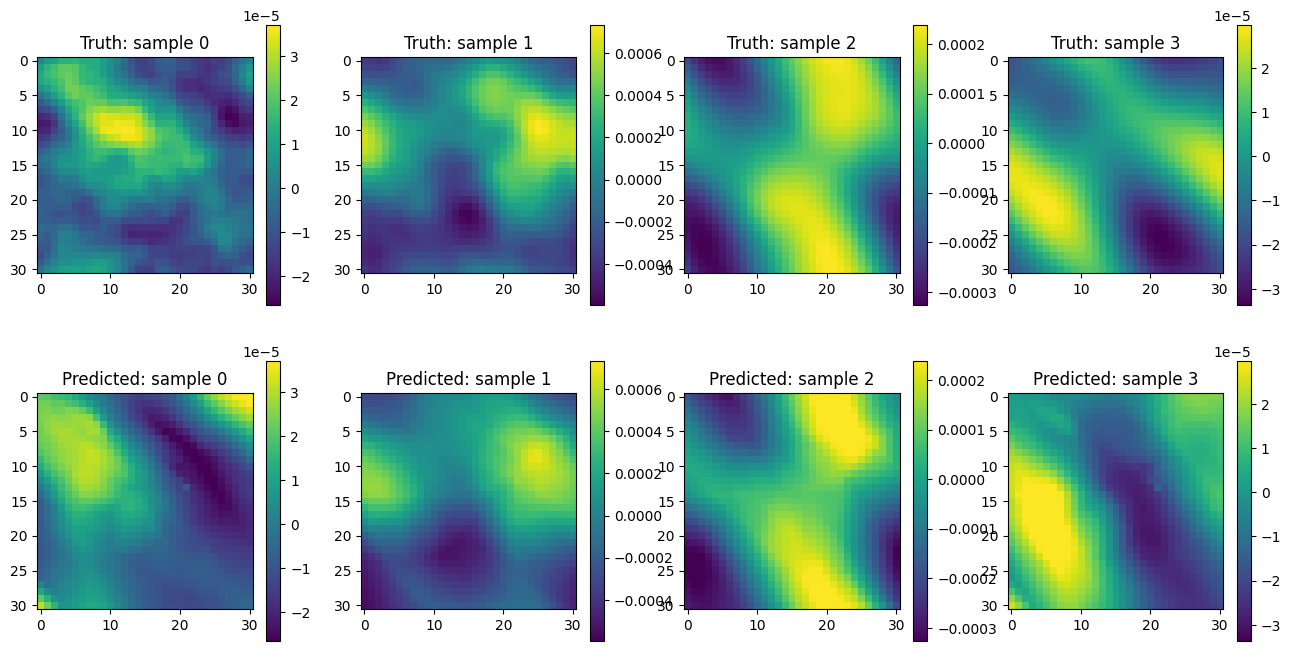

In [10]:
visualize_predictions_truth(ml_model, test_loader)

# Load the trained router

In [11]:
ckp_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}_best.pth"
save_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}"
args_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}args.json"
print(args_path)
if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
else:
    raise ValueError("Router Args Path Not found")
if model_type == "lstm":
    print(f"HERE")
    if dim == 1:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    else:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    # router = LSTMGreedyRouter(None, ml_arguments["N"]*(in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], num_solvers, arguments["dropout"]).to(device)
elif model_type == "lstm_side_info":
    if dim == 1:
        router = LSTMGreedyRouter_SideInfo(None, ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    else:
        router = LSTMGreedyRouter_SideInfo(None, ml_arguments["N"]*ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)

ckp = None
if os.path.exists(ckp_path):
    print(f"Loading model checkpoint from {ckp_path}...")
    ckp = torch.load(ckp_path, map_location=device)

if ckp:
    print(f"Loading router state dict...")
    router.load_state_dict(ckp["model"])
    print(f"Loaded router state dict")
if boundary == "Dirichlet":
    x = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32)
    y = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
else:
    x = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
    y = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None
pde = None
if equation == "Poisson":
    if dim == 1:
        pde = PoissonEquation1D(a_func= lambda x: 1,
                                f_func=lambda x: 1,
                                boundary=boundary,
                                x=x, 
                                device=device, 
                                solve = False)
    else:
        pde = PoissonEquation2D(a_func=lambda x, y: 1,
                                        f_func=lambda x,y: 1,
                                        boundary=boundary,
                                        x=x,
                                        y=y,
                                        device=device, 
                                        solve = False)
elif equation == "ConvDiff":
    pde = ConvectionDiffusion2D(a_func=lambda x, y: 1,
                                    f_func=lambda x, y: 1,
                                    b_vec=(b_vel, b_vel),
                                    boundary=boundary,
                                    x=x, y=y, device=device, 
                                    reaction=reaction_c,
                                    solve = False)
else:
    if dim == 1:
        pde = HelmholtzEquation1D(a_func= lambda x: 1, f_func=lambda x: 1, k2=lambda x: 1, boundary=boundary, x=x, device=device, solve = False)
    else:
        pde = HelmholtzEquation2D(a_func=lambda x, y: 1,f_func=lambda x,y: 1, k2=lambda x,y: 1, boundary=boundary,x=x,y=y, device=device, solve = False)


/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstm_side_inforouter_side_info_deeponet_hierarchical_ConvDiff_Periodic_2d_1c_mgargs.json
Loading training arguments from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstm_side_inforouter_side_info_deeponet_hierarchical_ConvDiff_Periodic_2d_1c_mgargs.json...
Loading model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstm_side_inforouter_side_info_deeponet_hierarchical_ConvDiff_Periodic_2d_1c_mg_best.pth...
Loading router state dict...
Loaded router state dict


In [12]:
list_of_solvers = []
numerical_solvers = solvers.split(",")
for solver in numerical_solvers:
    split = solver.split("_")
    print(solver)
    if len(split) > 2:
        raise ValueError("Invalid Numerical Solver")
    if split[0] == "jacobi":
        if len(split) > 1:
            weight = float(split[1])
        else:
            weight = 1
        list_of_solvers.append(WeightedJacobiSolver(pde, device, weight))
    elif split[0] == "gs":
        list_of_solvers.append(GaussSeidelSolver(pde, device))
    elif split[0] == "mg":
        if len(split) > 1:
            levels = int(split[1])
        else:
            levels = 2
        print(f"This is device {device}")
        list_of_solvers.append(MultigridSolver(pde, levels, device))
    else:
        raise ValueError("Invalid Numerical Solver")
print(list_of_solvers)
centered = equation == "Poisson" and boundary == "Periodic" and in_channels == 1

mg
This is device cuda


# Test the hybrid solver with the learned router

In [13]:
model = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                    suite_solver=list_of_solvers+[ml_model], router=router, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)
    
    
model.eval()
loss = ApproxGreedyRouterLoss(centered=(equation == "Poisson" and boundary == "Periodic"))
print(equation)
errors_greedy, loss_greedy, residuals_greedy, mode_one_greedy, mode_five_greedy, mode_ten_greedy, solver_decision_greedy = test_model(model, test_loader, in_channels, dim,loss, centered, loss_t = False)


ConvDiff


Iteration 1/100
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, conv

# Test the Jacobi-only method

In [14]:
constant_jacobi =  ConstantRouter(2, 0, device = device)
model_constant_jacobi = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=list_of_solvers+[ml_model], router=constant_jacobi, tol=1e-7, max_iters=max_iters, threshold=0.1).to(device)
loss = ApproxGreedyRouterLoss(centered=(equation == "Poisson" and boundary == "Periodic"))
errors_constant_jacobi, loss_constant_jacobi, residuals_constant_jacobi, mode_one_constant_jacobi, mode_five_constant_jacobi, mode_ten_constant_jacobi, solver_decision_constant_jacobi = test_model(model_constant_jacobi, test_loader, in_channels, dim, loss, centered, loss_t = False)


Iteration 1/100
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, conv

Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 3/16
Iteration 2, converged samples: 3/16
Max iterations reached without convergence.
Iteration 0, converged samples: 3/16
Iteration 1, converged samples: 3/16
Iteration 2, converged samples: 3/16
Max iterations reached without convergence.
Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 2/16
Iteration 2, converged samples: 2/16
Max iterations reached without convergence.
Iteration 0, converged samples: 3/16
Iteration 1, converged samples: 3/16
Iteration 2, converged samples: 3/16
Max iterations reached without convergence.
Iteration 0, converged samples: 3/16
Iteration 1, converged samples: 3/16
Iteration 2, converged samples: 3/16
Max iterations reached without convergence.
Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 2/16
Iteration 2, converged samples: 2/16
Max iterations reached without convergence.
Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 3

# Test HINTS

In [15]:
hints =  HINTSRouter(2, 25, device = device).to(device)
model_hints = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=list_of_solvers+[ml_model], router=hints, tol=1e-7, max_iters=max_iters, threshold=0.1).to(device)

errors_hints, loss_hints, residuals_hints , mode_one_hints, mode_five_hints, mode_ten_hints, solver_decision_hints = test_model(model_hints, test_loader, in_channels, dim, loss,  centered, loss_t = False)


Iteration 1/100
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, conv

Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0

# Test the true_greedy method

In [16]:
error_true, best_solver = true_greedy_model(model_hints, test_loader)

Iteration 1/100
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 0/16
Iteration 1, converged samples: 0/16
Iteration 2, converged samples: 0/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, converged samples: 1/16
Iteration 2, converged samples: 1/16
Max iterations reached without convergence.
Iteration 0, converged samples: 1/16
Iteration 1, conv

Iteration 0, converged samples: 4/16
Iteration 1, converged samples: 5/16
Iteration 2, converged samples: 5/16
Max iterations reached without convergence.
Iteration 0, converged samples: 5/16
Iteration 1, converged samples: 5/16
Iteration 2, converged samples: 5/16
Max iterations reached without convergence.
Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 2/16
Iteration 2, converged samples: 2/16
Max iterations reached without convergence.
Iteration 0, converged samples: 4/16
Iteration 1, converged samples: 5/16
Iteration 2, converged samples: 5/16
Max iterations reached without convergence.
Iteration 0, converged samples: 5/16
Iteration 1, converged samples: 5/16
Iteration 2, converged samples: 5/16
Max iterations reached without convergence.
Iteration 0, converged samples: 2/16
Iteration 1, converged samples: 2/16
Iteration 2, converged samples: 2/16
Max iterations reached without convergence.
Iteration 0, converged samples: 5/16
Iteration 1, converged samples: 5

In [17]:
print(best_solver.shape)

order_d = np.sum(best_solver, axis = 0)
sort_order = np.argsort(-1*order_d)
print(sort_order)
print(order_d)
print(np.sum(order_d >0)/n_samples)
print(np.sum(order_d > 1)/n_samples)
order_i = np.sum(solver_decision_greedy, axis = 0)
print(order_i)
print(np.sum(order_i > 0)/n_samples)
print(np.sum(order_i > 1)/n_samples)
print(np.argsort(-1*order_i))

(100, 64)
[59 14 41 16 36 46 35 53 21 22  7  1 10 12 23  2 44 47 52 49 54 55 62 51
 43 15  4  8  6  5  3  0 31 30 29 28 27 26 25 24 20 17 18 19 11  9 13 33
 45 42 40 32 34 37 38 39 48 50 57 56 58 60 61 63]
[0 1 1 0 0 0 0 1 0 0 1 0 1 0 2 0 2 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 2 2
 0 0 0 0 2 0 1 1 0 2 1 0 1 0 1 1 2 1 1 0 0 0 3 0 0 1 0]
0.390625
0.125
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
0.03125
0.03125
[59 36  0  1  4  5  2  3  8  9 10 11 12 13  6  7 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 14 15 31 30 34 32 35 37 38 33 40 41 42 43 44 45 46 39
 47 48 50 49 52 53 54 51 55 56 57 58 60 61 62 63]


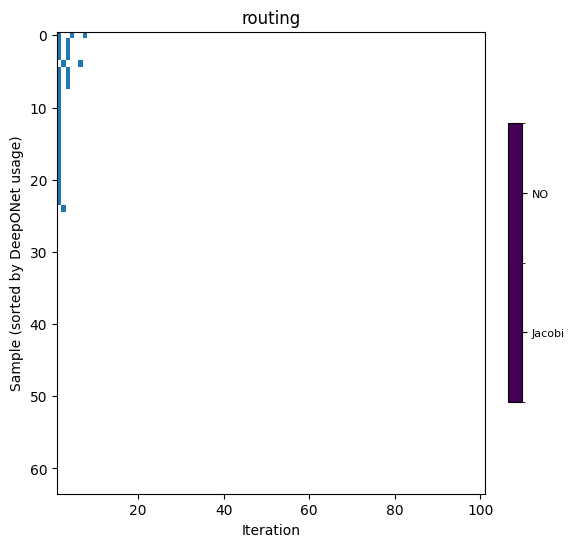

In [18]:
from matplotlib.colors import ListedColormap, BoundaryNorm
base_colors = plt.cm.tab10.colors
K = 2
cmap_colors = [base_colors[i % 10] for i in range(K)]
cmap = ListedColormap(cmap_colors[:K])
bounds = np.arange(-0.5, K + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)
fig = plt.figure(figsize=(6, 6))
best_solver_2 = np.zeros((best_solver.shape[0], best_solver.shape[1], 3))
best_solver_2[best_solver == 1] = np.array([0.12156862745098039, 0.4666666666666667, 0.7058823529411765])
best_solver_2[best_solver == 0] = np.array([1.0, 1.0, 1.0])
ax = fig.add_subplot(1, 1, 1)
im = ax.imshow(best_solver_2.transpose(1, 0, 2)[sort_order,:, :], aspect="auto",
                    interpolation="nearest", extent=[1, max_iters + 1, n_samples - 0.5, -0.5], norm = norm)
ax.set_xlabel("Iteration")
ax.set_ylabel("Sample (sorted by DeepONet usage)")
ax.set_title(f"routing")
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(K), fraction=0.03)
cbar.ax.set_yticklabels(["Jacobi", "NO"], fontsize=8)
plt.show()

(100, 64)


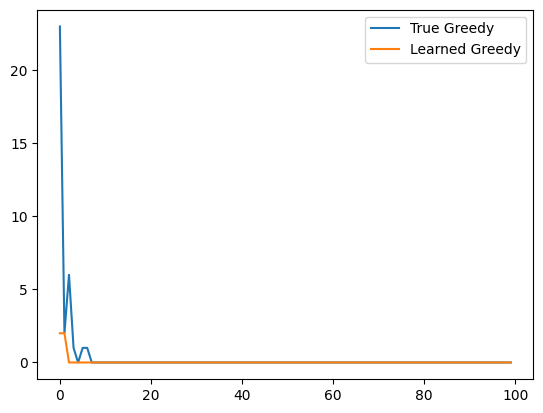

In [19]:
# Solver patterns
print(best_solver.shape)
# plt.plot(best_solver)
fig = plt.figure()
ax = fig.add_subplot(1,1, 1)
ax.plot(np.sum(best_solver, axis = -1), label = "True Greedy")
ax.plot(np.sum(solver_decision_greedy, axis = -1), label = "Learned Greedy")
ax.legend()

In [20]:
best_solver

array([[0, 1, 1, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 64))

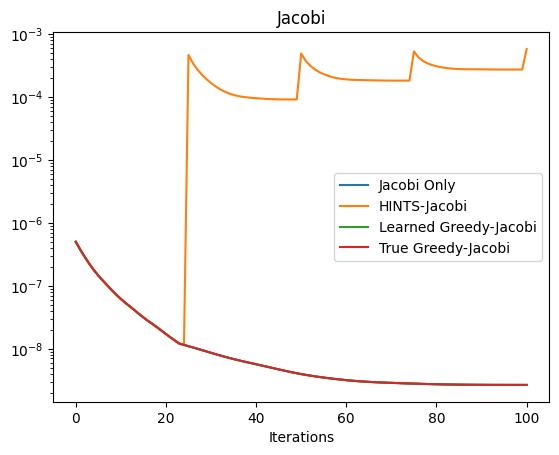

In [21]:
index_of_interest = 30
plt.plot(errors_constant_jacobi[:, index_of_interest], label='Jacobi Only')
plt.plot(errors_hints[:, index_of_interest], label='HINTS-Jacobi')
plt.plot(errors_greedy[:, index_of_interest], label='Learned Greedy-Jacobi')
plt.plot(error_true[:, index_of_interest], label = "True Greedy-Jacobi")
plt.legend()
plt.title("Jacobi")
plt.xlabel("Iterations")
plt.yscale("log")

In [22]:
auc_true = np.trapezoid(error_true, axis = 0)
auc_constant_jacobi = np.trapezoid(errors_constant_jacobi, axis = 0)
auc_hints = np.trapezoid(errors_hints, axis = 0)
auc_greedy = np.trapezoid(errors_greedy, axis = 0)
print(f"{np.mean(auc_true)} +/- {np.std(auc_true)}")
print(f"{np.mean(auc_constant_jacobi)} +/- {np.std(auc_constant_jacobi)}")
print(f"{np.mean(auc_hints)} +/- {np.std(auc_hints)}")
print(f"{np.mean(auc_greedy)} +/- {np.std(auc_greedy)}")


0.011974434368312359 +/- 0.0267542265355587
0.017446134239435196 +/- 0.04536008462309837
0.03267520293593407 +/- 0.03996742144227028
0.018840795382857323 +/- 0.056699346750974655


[ 0.01709401  0.01546736  0.01650092  0.0170973   0.0171572   0.01678367
  0.01713753  0.01478554  0.01678632  0.01712504  0.01398169  0.01715741
  0.01551389  0.01715664  0.01280221  0.0171383   0.00662029  0.01715597
  0.01715197  0.01715005  0.01713956  0.0168624   0.01558317  0.01571411
  0.01687936  0.01696956  0.01713719  0.01715559  0.01715654  0.01715458
  0.01715657  0.01715587  0.01691019  0.01715466  0.01714099  0.01647084
 -0.14823583  0.01715064  0.01711999  0.0170902   0.0171552   0.01656176
  0.01715364  0.01508635  0.01650525  0.01715684 -0.0052752   0.0170431
  0.01707994  0.01686995  0.0171569   0.01481996  0.01526829  0.01636872
  0.01582543  0.0143474   0.0171398   0.01715738  0.01715137  0.03592482
  0.01714654  0.01711896  0.01685834  0.01715195]
0.013834409
0.0


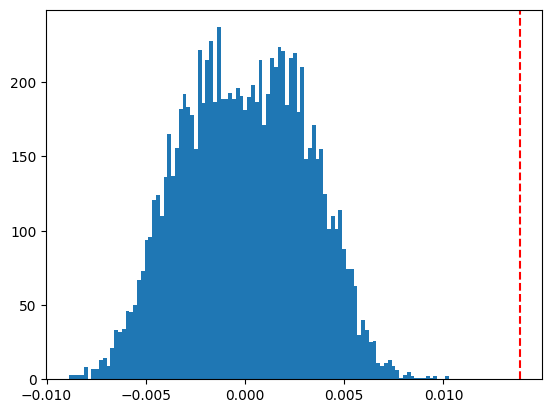

In [43]:
diff = auc_hints - auc_greedy
print(diff)
t_obs = diff.mean()
print(t_obs)
n_perm = 10000
signs = np.random.choice([-1.0, 1.0], size = (n_perm, diff.size))
t_perm = (signs * diff).mean(axis = 1)
pval = np.sum(t_perm >= t_obs)/n_perm
print(pval)
plt.hist(t_perm, bins = 100)
plt.axvline(x=t_obs, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')


0.013834409
0.020798711106181145
7.277987901233018e-07


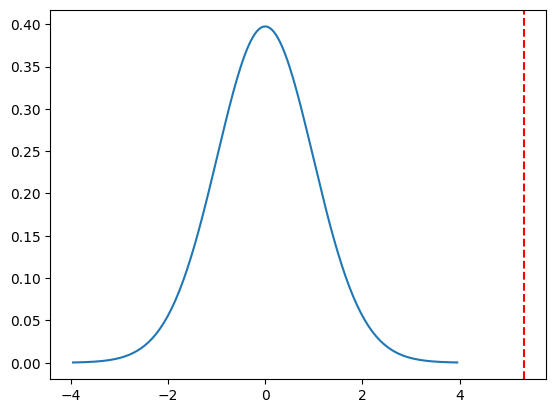

In [44]:
from scipy.stats import t
stdd = np.std(diff)
print(t_obs)
print(f"{np.std(diff)}")
test_stat = t_obs/(stdd/np.sqrt(n_samples))
df = n_samples - 1
print(1-t.cdf(test_stat, df))
x = np.linspace(t.ppf(0.0001, df),
                t.ppf(0.9999, df), 200)
plt.plot(x, t.pdf(x, df),  label='t pdf')
plt.axvline(x=test_stat, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')

In [25]:
from scipy.stats import ttest_rel
ttest_rel(auc_hints, auc_greedy, alternative="greater").pvalue

np.float64(8.523462746472395e-07)

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -0.0017397   0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -0.00032149
  0.          0.          0.          0.        ]
-3.2206106e-05
0.0002187868085457012
0.8783121660017789


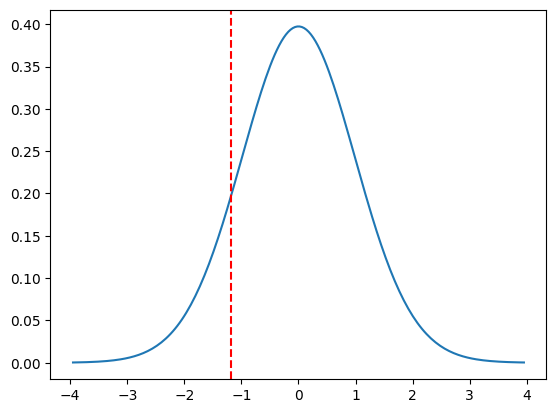

In [26]:
diff_2 = errors_constant_jacobi[-1] - errors_greedy[-1]
print(diff_2)
t_obs = diff_2.mean()
stdd = np.std(diff_2)
print(t_obs)
print(f"{np.std(diff_2)}")
test_stat = t_obs/(stdd/np.sqrt(n_samples))
df = n_samples - 1
print(1-t.cdf(test_stat, df))
x = np.linspace(t.ppf(0.0001, df),
                t.ppf(0.9999, df), 200)
plt.plot(x, t.pdf(x, df),  label='t pdf')
plt.axvline(x=test_stat, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')

In [27]:
df_error = pd.DataFrame({"Methods": ["jacobi only", "HINTS-jacobi", "Greedy-jacobi", "True-Greedy-jacobi","gs only", "HINTS-gs", "Greedy-gs", "True-Greedy-gs", "Greedy-gs,jacobi", "mg only", "HINTS-mg", "Greedy-mg", "True-Greedy-mg"]})
df_error["FinalError_2d_Poisson"] = ""
df_error["AUC_Error_2d_Poisson"] = ""

df_error["FinalError_2d_Helmholtz"] = ""
df_error["AUC_Error_2d_Helmholtz"] = ""

df_error["FinalError_2d_Convdiff"] = ""
df_error["AUC_Error_2d_Convdiff"] = ""
df_error = df_error.set_index("Methods")

In [28]:
df_error

,FinalError_2d_Poisson,AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,AUC_Error_2d_Convdiff
Methods,,,,,,
jacobi only,,,,,,
HINTS-jacobi,,,,,,
Greedy-jacobi,,,,,,
True-Greedy-jacobi,,,,,,
gs only,,,,,,
HINTS-gs,,,,,,
Greedy-gs,,,,,,
True-Greedy-gs,,,,,,
"Greedy-gs,jacobi",,,,,,


In [29]:
df_error.loc["jacobi only", "AUC_Error_2d_Poisson"] = f"{(np.mean(errors_constant_jacobi[-1])*(10**3)).item():.3f} ({(np.std(errors_constant_jacobi[-1])*(10**3)).item():.3f})"

In [30]:
if os.path.exists(f"../results/separate_{ml_model_type}_{ml_model_name}_error_comparison.csv"):
    df_error = pd.read_csv(f"../results/separate_{ml_model_type}_{ml_model_name}_error_comparison.csv")
    df_error.set_index("Methods", inplace = True)

In [31]:
df_error

,FinalError_2d_Poisson,Mean_FinalError_2d_Poisson,Std_FinalError_2d_Poisson,pval_FinalError_2d_Poisson,AUC_Error_2d_Poisson,Mean_AUC_Error_2d_Poisson,Std_AUC_Error_2d_Poisson,pval_AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,Mean_FinalError_2d_Helmholtz,...,Std_AUC_Error_2d_Helmholtz,pval_AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,Mean_FinalError_2d_Convdiff,Std_FinalError_2d_Convdiff,pval_FinalError_2d_Convdiff,AUC_Error_2d_Convdiff,Mean_AUC_Error_2d_Convdiff,Std_AUC_Error_2d_Convdiff,pval_AUC_Error_2d_Convdiff
Methods,,,,,,,,,,,,,,,,,,,,,
jacobi only,0.496 (1.213),4.958621e-04,1.213320e-03,1.645181e-03,1.064 (2.553),1.063812,2.552661,1.363963e-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HINTS-jacobi,0.761 (0.019),7.613670e-04,1.934074e-05,5.290220e-48,0.463 (0.716),0.463369,0.716048,1.336957e-06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-jacobi,0.058 (0.137),5.831372e-05,1.367827e-04,NaN,0.187 (0.372),0.186512,0.372057,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-jacobi,0.022 (0.018),2.201438e-05,1.828978e-05,NaN,0.113 (0.207),0.113240,0.207268,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gs only,0.025 (0.060),2.453248e-05,6.003496e-05,1.751365e-03,0.563 (1.350),0.562705,1.350469,1.393885e-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HINTS-gs,0.724 (0.000),7.243844e-04,3.321720e-08,1.874376e-111,0.382 (0.582),0.382109,0.582431,4.302712e-09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-gs,0.006 (0.013),6.173718e-06,1.317386e-05,NaN,0.161 (0.341),0.161272,0.340656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-gs,0.001 (0.001),1.125666e-06,9.083818e-07,NaN,0.067 (0.123),0.066889,0.122807,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mg only,0.000 (0.000),4.043122e-08,9.834797e-08,9.999941e-01,0.062 (0.149),0.061979,0.148734,1.194257e-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df_error[["FinalError_2d_Poisson","pval_FinalError_2d_Poisson", "AUC_Error_2d_Poisson", "pval_AUC_Error_2d_Poisson"]].to_latex()

'\\begin{tabular}{llrlr}\n\\toprule\n & FinalError_2d_Poisson & pval_FinalError_2d_Poisson & AUC_Error_2d_Poisson & pval_AUC_Error_2d_Poisson \\\\\nMethods &  &  &  &  \\\\\n\\midrule\njacobi only & 0.496 (1.213) & 0.001645 & 1.064 (2.553) & 0.001364 \\\\\nHINTS-jacobi & 0.761 (0.019) & 0.000000 & 0.463 (0.716) & 0.000001 \\\\\nLearned Greedy-jacobi & 0.058 (0.137) & NaN & 0.187 (0.372) & NaN \\\\\nTrue-Greedy-jacobi & 0.022 (0.018) & NaN & 0.113 (0.207) & NaN \\\\\ngs only & 0.025 (0.060) & 0.001751 & 0.563 (1.350) & 0.001394 \\\\\nHINTS-gs & 0.724 (0.000) & 0.000000 & 0.382 (0.582) & 0.000000 \\\\\nLearned Greedy-gs & 0.006 (0.013) & NaN & 0.161 (0.341) & NaN \\\\\nTrue-Greedy-gs & 0.001 (0.001) & NaN & 0.067 (0.123) & NaN \\\\\nmg only & 0.000 (0.000) & 0.999994 & 0.062 (0.149) & 0.011943 \\\\\nHINTS-mg & 0.081 (0.000) & 0.000000 & 0.077 (0.139) & 0.000000 \\\\\nLearned Greedy-mg & 0.000 (0.000) & NaN & 0.050 (0.139) & NaN \\\\\nTrue-Greedy-mg & 0.000 (0.000) & NaN & 0.018 (0.038) &

In [33]:
if os.path.exists(f"../results/multiple_solvers_{ml_model_type}_{ml_model_name}_error_comparison.csv"):
    df_error = pd.read_csv(f"../results/multiple_solvers_{ml_model_type}_{ml_model_name}_error_comparison.csv")
    df_error.set_index("Methods", inplace = True)
df_error

,FinalError_2d_Poisson,Mean_FinalError_2d_Poisson,Std_FinalError_2d_Poisson,AUC_Error_2d_Poisson,Mean_AUC_Error_2d_Poisson,Std_AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,Mean_FinalError_2d_Helmholtz,Std_FinalError_2d_Helmholtz,AUC_Error_2d_Helmholtz,Mean_AUC_Error_2d_Helmholtz,Std_AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,Mean_FinalError_2d_Convdiff,Std_FinalError_2d_Convdiff,AUC_Error_2d_Convdiff,Mean_AUC_Error_2d_Convdiff,Std_AUC_Error_2d_Convdiff
Methods,,,,,,,,,,,,,,,,,,
Learned Greedy-Jacobi w/ 2 solvers,0.298 (1.113),2.975624e-04,1.113045e-03,0.657 (2.305),0.656563,2.304565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 2 solvers,0.022 (0.018),2.201438e-05,1.828978e-05,0.113 (0.207),0.113240,0.207268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 3 solvers,0.223 (0.914),2.230104e-04,9.135016e-04,0.521 (1.899),0.521176,1.899470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 3 solvers,0.021 (0.017),2.122573e-05,1.654292e-05,0.113 (0.207),0.113094,0.206755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 4 solvers,0.496 (1.213),4.958621e-04,1.213320e-03,1.064 (2.553),1.063812,2.552661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 4 solvers,0.069 (0.145),6.858855e-05,1.454958e-04,0.178 (0.391),0.177718,0.391256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 5 solvers,0.649 (2.041),6.489647e-04,2.041152e-03,0.934 (2.735),0.933743,2.734833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 5 solvers,0.021 (0.017),2.122573e-05,1.654292e-05,0.113 (0.207),0.113094,0.206755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 6 solvers,0.575 (1.991),5.751696e-04,1.991295e-03,0.865 (2.844),0.864556,2.844497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df_error[["FinalError_2d_Poisson", "AUC_Error_2d_Poisson"]].to_latex()

'\\begin{tabular}{lll}\n\\toprule\n & FinalError_2d_Poisson & AUC_Error_2d_Poisson \\\\\nMethods &  &  \\\\\n\\midrule\nLearned Greedy-Jacobi w/ 2 solvers & 0.298 (1.113) & 0.657 (2.305) \\\\\nTrue-Greedy-Jacobi w/ 2 solvers & 0.022 (0.018) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 3 solvers & 0.223 (0.914) & 0.521 (1.899) \\\\\nTrue-Greedy-Jacobi w/ 3 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 4 solvers & 0.496 (1.213) & 1.064 (2.553) \\\\\nTrue-Greedy-Jacobi w/ 4 solvers & 0.069 (0.145) & 0.178 (0.391) \\\\\nLearned Greedy-Jacobi w/ 5 solvers & 0.649 (2.041) & 0.934 (2.735) \\\\\nTrue-Greedy-Jacobi w/ 5 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 6 solvers & 0.575 (1.991) & 0.865 (2.844) \\\\\nTrue-Greedy-Jacobi w/ 6 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-SOR w/ 2 solvers & NaN & NaN \\\\\nTrue-Greedy-SOR w/ 2 solvers & NaN & NaN \\\\\nLearned Greedy-SOR w/ 3 solvers & 0.001 (0.006) & 0.186 (0.627) \\\\

In [35]:
results_dir = "../results"

In [36]:
if os.path.exists(f"../results/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_solver_decisions_2.pkl"):
    fig, axes = pickle.load(open(f"{results_dir}/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_solver_decisions_2.pkl", "rb"))

[[1 0 1 ... 1 0 0]
 [0 1 0 ... 0 0 0]
 [1 1 1 ... 0 1 0]
 ...
 [1 0 0 ... 0 1 0]
 [1 0 1 ... 1 1 0]
 [1 0 0 ... 0 1 1]]


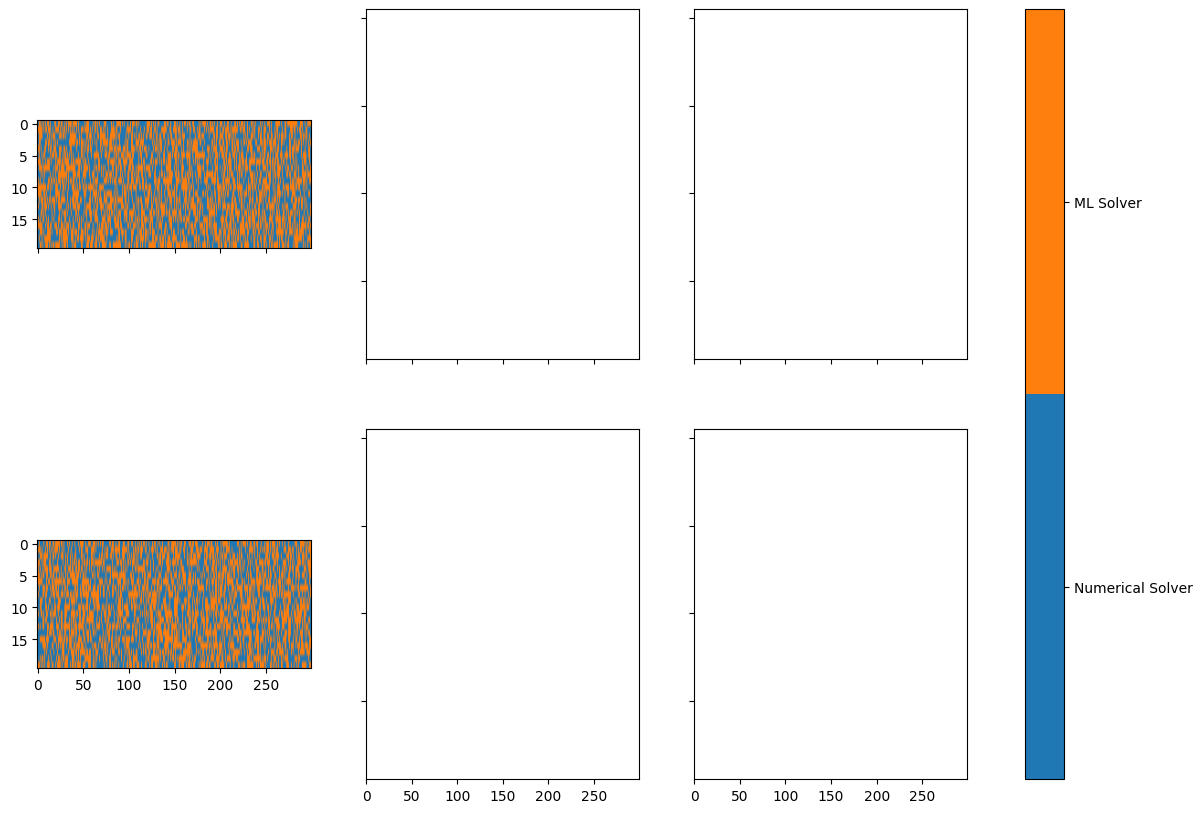

In [37]:
from matplotlib import colors
fig, axes = plt.subplots(ncols = 3, nrows = 2, sharey = True, sharex = True, figsize = (15, 10))
jac_decision = np.random.randint(low = 0, high = 2, size = (300, 20))
print(jac_decision)
two_colors = ["tab:blue", "tab:orange"]
cmap = colors.ListedColormap(two_colors)
ax = axes[0, 0].imshow(jac_decision.transpose(), cmap = cmap, aspect = 7)
true_jac_decision = np.random.randint(low = 0, high = 2, size = (300, 20))
axes[1, 0].imshow(true_jac_decision.transpose(), cmap = cmap, aspect = 7)
cbar = fig.colorbar(ax, ax = axes, location = "right")
cbar.ax.yaxis.set_label_position("right")
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(["Numerical Solver", "ML Solver"])

In [38]:
num_solvers = 2

In [39]:
np.linspace((num_solvers - 1)/(2*num_solvers), (num_solvers - 1)/(2*num_solvers) + (num_solvers - 1)*(num_solvers - 1)/(num_solvers), num_solvers)

array([0.25, 0.75])